In [9]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


df = pd.read_csv("emails.csv")
print(df.head())

X = df["text"]
y = df["spam"]



X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)



                                                text  spam
0  Subject: naturally irresistible your corporate...     1
1  Subject: the stock trading gunslinger  fanny i...     1
2  Subject: unbelievable new homes made easy  im ...     1
3  Subject: 4 color printing special  request add...     1
4  Subject: do not have money , get software cds ...     1


In [10]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:",
      accuracy_score(y_test, nb_pred))

print(classification_report(y_test, nb_pred))



Naive Bayes Accuracy: 0.9781849912739965
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       856
           1       0.99      0.93      0.96       290

    accuracy                           0.98      1146
   macro avg       0.98      0.96      0.97      1146
weighted avg       0.98      0.98      0.98      1146



In [11]:
svm_model = SVC(kernel="linear")
svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

print("SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.9921465968586387
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       856
           1       0.99      0.98      0.98       290

    accuracy                           0.99      1146
   macro avg       0.99      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146



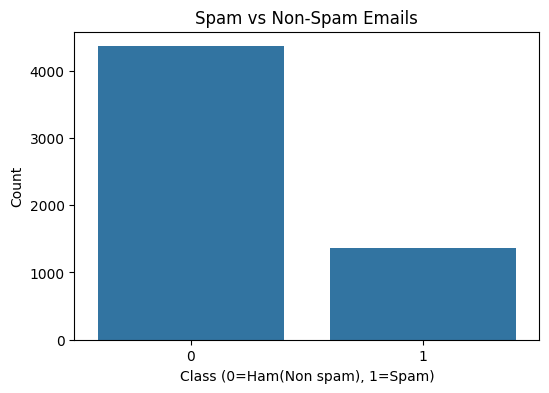

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='spam', data=df)
plt.title("Spam vs Non-Spam Emails")
plt.xlabel("Class (0=Ham(Non spam), 1=Spam)")
plt.ylabel("Count")
plt.show()

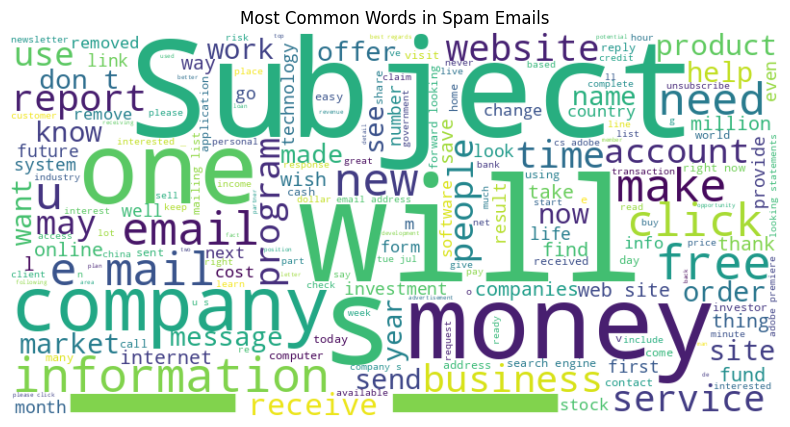

In [14]:
from wordcloud import WordCloud

spam_words = " ".join(df[df['spam']==1]['text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Words in Spam Emails")
plt.show()

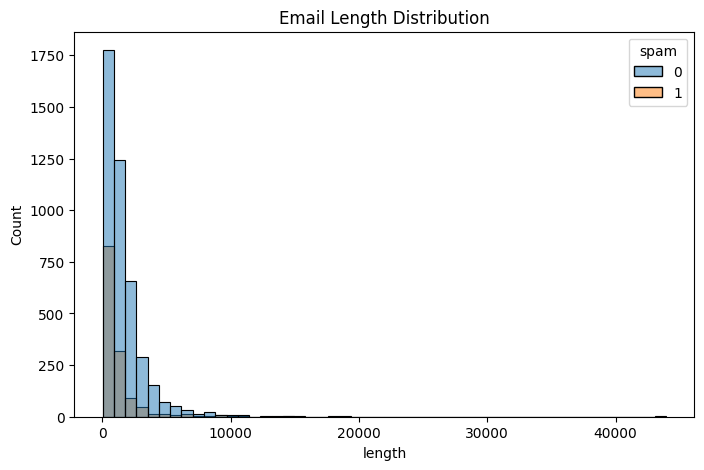

In [15]:
df['length'] = df['text'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='length',
    hue='spam',
    bins=50
)
plt.title("Email Length Distribution")
plt.show()

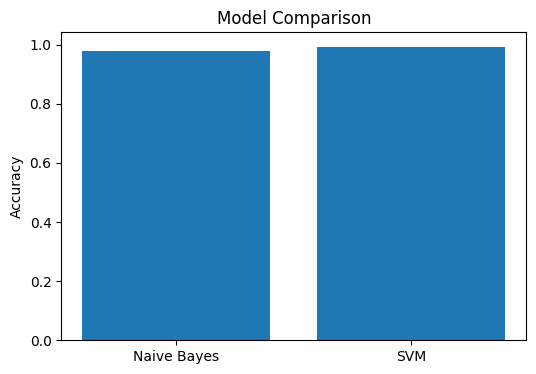

In [17]:
models = ['Naive Bayes', 'SVM']

# Recalculate accuracy scores since they were not stored in variables
nb_acc = accuracy_score(y_test, nb_pred)
svm_acc = accuracy_score(y_test, svm_pred)

accuracy = [nb_acc, svm_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()